In [1]:
# FBA1049 Asset Pricing - CA2
# Group 9 - UNH (UnitedHealth Group)

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Download 20 years of daily data
ticker = 'UNH'

unh = yf.download(ticker, start='2004-01-01', end='2024-12-31', auto_adjust=True, progress=False)
sp500 = yf.download('^GSPC', start='2004-01-01', end='2024-12-31', auto_adjust=True, progress=False)
nasdaq = yf.download('^IXIC', start='2004-01-01', end='2024-12-31', auto_adjust=True, progress=False)

# Flatten columns if needed
for df in [unh, sp500, nasdaq]:
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

# Build price and returns dataframes
prices = pd.DataFrame({
    'UNH': unh['Close'],
    'SP500': sp500['Close'],
    'NASDAQ': nasdaq['Close']
}).dropna()

returns = prices.pct_change().dropna()

print(f'Rows loaded: {len(prices)}')
print(prices.head())

Rows loaded: 5284
                  UNH        SP500       NASDAQ
Date                                           
2004-01-02  22.755630  1108.479980  2006.680054
2004-01-05  21.661009  1122.219971  2047.359985
2004-01-06  21.884554  1123.670044  2057.370117
2004-01-07  22.088829  1126.329956  2077.679932
2004-01-08  22.135090  1131.920044  2100.250000


In [3]:
Summary_stat = round(returns.describe(), 6)
print(Summary_stat)

               UNH        SP500       NASDAQ
count  5283.000000  5283.000000  5283.000000
mean      0.000765     0.000388     0.000521
std       0.019212     0.011885     0.013467
min      -0.186362    -0.119841    -0.123213
25%      -0.007700    -0.004086    -0.005354
50%       0.000716     0.000709     0.001035
75%       0.009143     0.005658     0.007240
max       0.347550     0.115800     0.118059


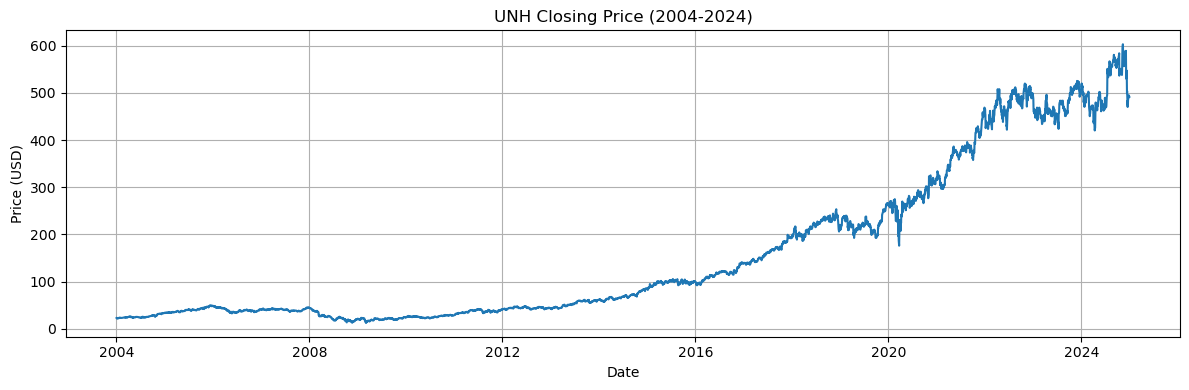

In [4]:
# Plot UNH price history
plt.figure(figsize=(12, 4))
plt.plot(prices['UNH'])
plt.title('UNH Closing Price (2004-2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# Part 1 - Normality of returns
unh_ret = returns['UNH']

print('Descriptive stats:')
print(f'  Mean      : {unh_ret.mean():.6f}')
print(f'  Std dev   : {unh_ret.std():.6f}')
print(f'  Skewness  : {unh_ret.skew():.4f}')
print(f'  Kurtosis  : {unh_ret.kurtosis():.4f}')

#Hypotheses of the Jarque-Bera Test
#Null Hypothesis (0): The data is normally distributed.
#Alternative Hypothesis (1): The data is not normally distributed.

jb_stat, jb_p = stats.jarque_bera(unh_ret)
print(f'\nJarque-Bera (n={len(unh_ret)}): stat={jb_stat:.4f}, p={jb_p:.6f}')

if jb_p < 0.05:
    print('Returns are NOT normally distributed (p < 0.05)')
else:
    print('Cannot reject normality at 5% level')

Descriptive stats:
  Mean      : 0.000765
  Std dev   : 0.019212
  Skewness  : 0.9607
  Kurtosis  : 31.1861

Jarque-Bera (n=5283): stat=214479.2088, p=0.000000
Returns are NOT normally distributed (p < 0.05)


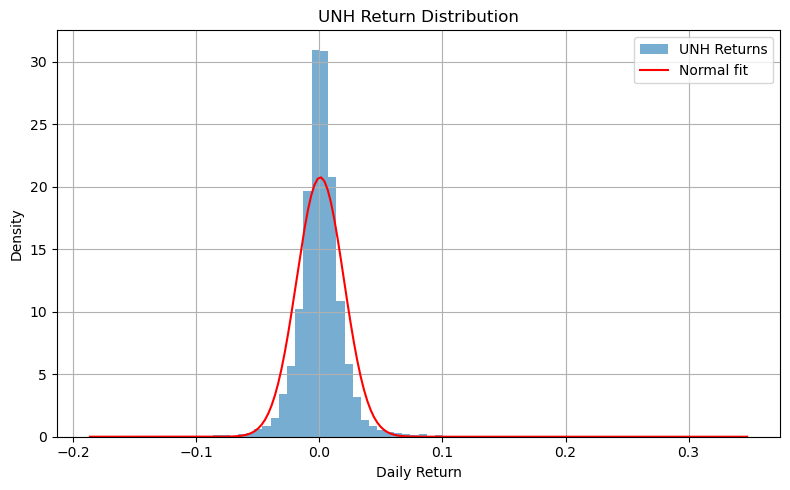

In [6]:
# Histogram of returns vs normal distribution
plt.figure(figsize=(8, 5))
plt.hist(unh_ret, bins=80, density=True, alpha=0.6, label='UNH Returns')
x = np.linspace(unh_ret.min(), unh_ret.max(), 200)
plt.plot(x, stats.norm.pdf(x, unh_ret.mean(), unh_ret.std()), 'r-', label='Normal fit')
plt.title('UNH Return Distribution')
plt.xlabel('Daily Return')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

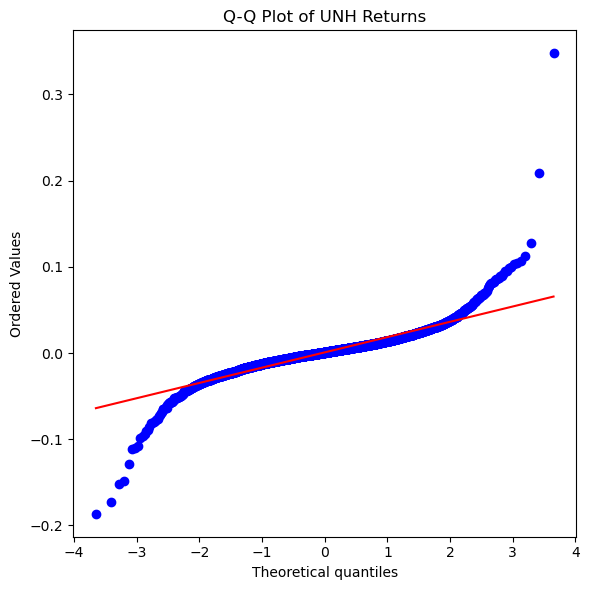

In [7]:
# QQ Plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(unh_ret, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of UNH Returns')
plt.tight_layout()
plt.show()

In [8]:
# UNH vs S&P 500
X_sp = sm.add_constant(returns['SP500'])
model_sp = sm.OLS(unh_ret, X_sp).fit()
corr_sp = unh_ret.corr(returns['SP500'])

print('vs SP500:')
print(f'  Correlation : {corr_sp:.4f}')
print(f'  R-squared   : {model_sp.rsquared:.4f}')
print(f'  Alpha       : {model_sp.params.iloc[0]:.6f} (p={model_sp.pvalues.iloc[0]:.4f})')
print(f'  Beta        : {model_sp.params.iloc[1]:.4f} (p={model_sp.pvalues.iloc[1]:.6f})')
print()
print(model_sp.summary())

vs SP500:
  Correlation : 0.5588
  R-squared   : 0.3123
  Alpha       : 0.000415 (p=0.0586)
  Beta        : 0.9034 (p=0.000000)

                            OLS Regression Results                            
Dep. Variable:                    UNH   R-squared:                       0.312
Model:                            OLS   Adj. R-squared:                  0.312
Method:                 Least Squares   F-statistic:                     2398.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:41:41   Log-Likelihood:                 14373.
No. Observations:                5283   AIC:                        -2.874e+04
Df Residuals:                    5281   BIC:                        -2.873e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--

In [9]:
# UNH vs NASDAQ
X_nq = sm.add_constant(returns['NASDAQ'])
model_nq = sm.OLS(unh_ret, X_nq).fit()
corr_nq = unh_ret.corr(returns['NASDAQ'])

print('vs NASDAQ:')
print(f'  Correlation : {corr_nq:.4f}')
print(f'  R-squared   : {model_nq.rsquared:.4f}')
print(f'  Alpha       : {model_nq.params.iloc[0]:.6f} (p={model_nq.pvalues.iloc[0]:.4f})')
print(f'  Beta        : {model_nq.params.iloc[1]:.4f} (p={model_nq.pvalues.iloc[1]:.6f})')
print()
print(model_nq.summary())

vs NASDAQ:
  Correlation : 0.4887
  R-squared   : 0.2388
  Alpha       : 0.000402 (p=0.0819)
  Beta        : 0.6971 (p=0.000000)

                            OLS Regression Results                            
Dep. Variable:                    UNH   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.239
Method:                 Least Squares   F-statistic:                     1657.
Date:                Sat, 04 Apr 2026   Prob (F-statistic):          2.77e-315
Time:                        18:41:41   Log-Likelihood:                 14105.
No. Observations:                5283   AIC:                        -2.821e+04
Df Residuals:                    5281   BIC:                        -2.819e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-

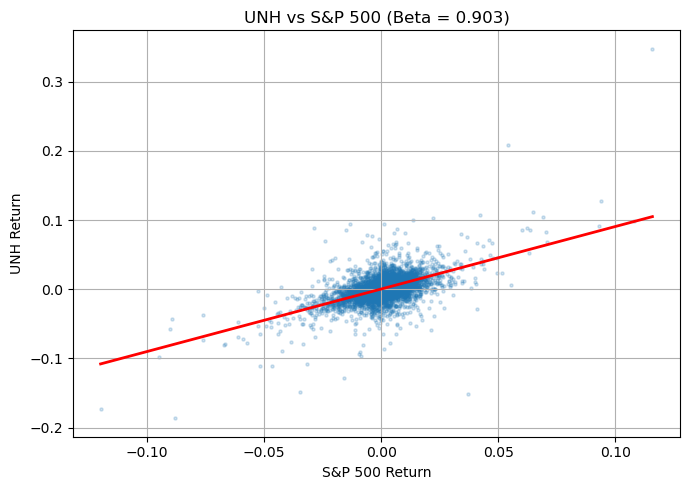

In [10]:
# Scatter plot vs S&P 500
plt.figure(figsize=(7, 5))
plt.scatter(returns['SP500'], unh_ret, alpha=0.2, s=5)
m, b = np.polyfit(returns['SP500'], unh_ret, 1)
x_line = np.linspace(returns['SP500'].min(), returns['SP500'].max(), 100)
plt.plot(x_line, m * x_line + b, 'r-', linewidth=2)
plt.title(f'UNH vs S&P 500 (Beta = {m:.3f})')
plt.xlabel('S&P 500 Return')
plt.ylabel('UNH Return')
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Part 2 - Random Walk / Time Series
log_prices = np.log(prices['UNH'])

# ADF test on log prices
adf = adfuller(log_prices, autolag='AIC')
print('ADF Test on log prices:')
print(f'  ADF stat : {adf[0]:.4f}')
print(f'  p-value  : {adf[1]:.6f}')
print(f'  Crit 5%  : {adf[4]["5%"]:.4f}')

if adf[1] > 0.05:
    print('  Cannot reject unit root - log prices follow a random walk')
else:
    print('  Reject unit root - log prices are stationary')

# ADF on returns
adf_ret = adfuller(unh_ret, autolag='AIC')
print(f'\nADF Test on returns:')
print(f'  ADF stat : {adf_ret[0]:.4f}')
print(f'  p-value  : {adf_ret[1]:.6f}')
if adf_ret[1] < 0.05:
    print('  Returns are stationary - confirms random walk in price levels')

ADF Test on log prices:
  ADF stat : -0.0119
  p-value  : 0.957539
  Crit 5%  : -2.8621
  Cannot reject unit root - log prices follow a random walk

ADF Test on returns:
  ADF stat : -16.6163
  p-value  : 0.000000
  Returns are stationary - confirms random walk in price levels


In [12]:
# Random walk simulation - 100 paths, 1 year forward
last_price = float(prices['UNH'].iloc[-1])
mu = float(unh_ret.mean())
sigma = float(unh_ret.std())
n_days = 252
n_sims = 100

np.random.seed(42)
sims = np.zeros((n_days, n_sims))
for i in range(n_sims):
    r = np.random.normal(mu, sigma, n_days)
    sims[:, i] = last_price * np.cumprod(1 + r)

print(f'Starting price   : ${last_price:.2f}')
print(f'Median (1yr)     : ${np.median(sims[-1]):.2f}')
print(f'5th percentile   : ${np.percentile(sims[-1], 5):.2f}')
print(f'95th percentile  : ${np.percentile(sims[-1], 95):.2f}')

Starting price   : $491.77
Median (1yr)     : $578.34
5th percentile   : $384.47
95th percentile  : $907.33


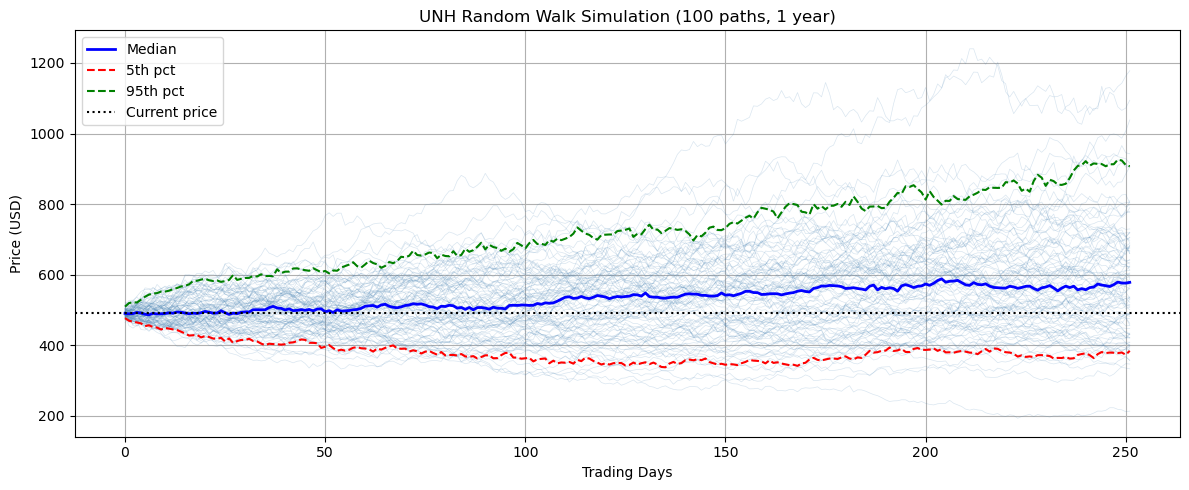

In [13]:
# Plot random walk simulation
plt.figure(figsize=(12, 5))
for i in range(n_sims):
    plt.plot(sims[:, i], color='steelblue', alpha=0.2, linewidth=0.5)
plt.plot(np.median(sims, axis=1), color='blue', linewidth=2, label='Median')
plt.plot(np.percentile(sims, 5, axis=1), 'r--', linewidth=1.5, label='5th pct')
plt.plot(np.percentile(sims, 95, axis=1), 'g--', linewidth=1.5, label='95th pct')
plt.axhline(last_price, color='black', linestyle=':', label='Current price')
plt.title('UNH Random Walk Simulation (100 paths, 1 year)')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The fan of blue paths spreading wider and wider as time goes on is the visual proof of the random walk — uncertainty compounds over time. Even though the median trends upward, the range between $390 and $920 at the one year mark shows that the model gives you very little precision about where the price will actually land. This is a strong visual argument that price prediction using simple statistical models is fundamentally limited, which ties directly into the debate between Cochrane's traditional view and the complexity argument.

In [14]:
# Part 3 - CAPM Beta
rf_annual = 0.043
rf_daily = rf_annual / 252

excess_unh = unh_ret - rf_daily

for mkt, label in [('SP500', 'S&P 500'), ('NASDAQ', 'NASDAQ')]:
    excess_mkt = returns[mkt] - rf_daily
    X = sm.add_constant(excess_mkt)
    capm = sm.OLS(excess_unh, X).fit()

    # Simple OLS beta for comparison
    X2 = sm.add_constant(returns[mkt])
    ols_beta = sm.OLS(unh_ret, X2).fit().params.iloc[1]

    print(f'CAPM vs {label}:')
    print(f'  CAPM Beta      : {capm.params.iloc[1]:.4f}')
    print(f'  Jensen Alpha   : {capm.params.iloc[0]:.6f} (p={capm.pvalues.iloc[0]:.4f})')
    print(f'  Simple OLS Beta: {ols_beta:.4f}')
    print(f'  Difference     : {capm.params.iloc[1] - ols_beta:.6f}')
    print()

CAPM vs S&P 500:
  CAPM Beta      : 0.9034
  Jensen Alpha   : 0.000398 (p=0.0693)
  Simple OLS Beta: 0.9034
  Difference     : -0.000000

CAPM vs NASDAQ:
  CAPM Beta      : 0.6971
  Jensen Alpha   : 0.000350 (p=0.1294)
  Simple OLS Beta: 0.6971
  Difference     : 0.000000



## Financial Analysis Data Sheet Export
The cell below saves all key results to an Excel file (`.xlsx`) and a PDF summary. Run this after all analysis cells have been executed.

In [15]:
# ─────────────────────────────────────────────
# FINANCIAL ANALYSIS DATA SHEET EXPORT
# Saves results to Excel (.xlsx) and PDF
# ─────────────────────────────────────────────

import os
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from scipy import stats as sp_stats
import statsmodels.api as sm2
import numpy as np

output_dir = 'CA2_Data_Sheet'
os.makedirs(output_dir, exist_ok=True)

# ── Style helpers
NAVY  = '1E2761'
ICE   = 'CADCFC'
WHITE = 'FFFFFF'
LIGHT = 'F4F6FB'
ACC   = '4A90D9'

def thin_border():
    s = Side(style='thin', color='CADCFC')
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, row, col, value, bg=NAVY, fg=WHITE, size=11, bold=True):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(bold=bold, color=fg, size=size, name='Arial')
    c.fill = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    return c

def cv(ws, row, col, value, bg=WHITE, fg='1E2761', align='center', bold=False):
    c = ws.cell(row=row, column=col, value=value)
    c.font = Font(bold=bold, color=fg, size=10, name='Arial')
    c.fill = PatternFill('solid', start_color=bg)
    c.alignment = Alignment(horizontal=align, vertical='center')
    c.border = thin_border()
    return c

# ── Re-compute all stats cleanly
X_sp2   = sm2.add_constant(returns['SP500'])
m_sp2   = sm2.OLS(unh_ret, X_sp2).fit()
X_nq2   = sm2.add_constant(returns['NASDAQ'])
m_nq2   = sm2.OLS(unh_ret, X_nq2).fit()

jb2, jb_p2 = sp_stats.jarque_bera(unh_ret)

log_p2   = np.log(prices['UNH'])
adf_p2   = adfuller(log_p2, autolag='AIC')
adf_r2   = adfuller(unh_ret, autolag='AIC')

rf2      = 0.043 / 252
ex_u2    = unh_ret - rf2
ex_sp2   = returns['SP500'] - rf2
ex_nq2   = returns['NASDAQ'] - rf2
c_sp2    = sm2.OLS(ex_u2, sm2.add_constant(ex_sp2)).fit()
c_nq2    = sm2.OLS(ex_u2, sm2.add_constant(ex_nq2)).fit()
obs_sp2  = m_sp2.params.iloc[1]
obs_nq2  = m_nq2.params.iloc[1]

# ══════════════════════════════════════════
# EXCEL
# ══════════════════════════════════════════
wb = Workbook()

# ── Sheet 1: Summary
ws1 = wb.active
ws1.title = 'Summary'
ws1.column_dimensions['A'].width = 34
ws1.column_dimensions['B'].width = 22
ws1.column_dimensions['C'].width = 22

ws1.merge_cells('A1:C1')
hdr(ws1, 1, 1, 'FBA1049 Asset Pricing CA2 — Financial Analysis Data Sheet', size=13)
ws1.row_dimensions[1].height = 28

ws1.merge_cells('A2:C2')
hdr(ws1, 2, 1, f'UNH (UnitedHealth Group) | 2004–2024 | {len(unh_ret)} Observations', bg=ACC, size=10)

# Descriptive
ws1.merge_cells('A4:C4')
hdr(ws1, 4, 1, 'Descriptive Statistics', bg=ACC)
hdr(ws1, 4, 1, 'Descriptive Statistics', bg=ACC)

desc = [
    ('Mean Daily Return',  f'{unh_ret.mean():.6f}'),
    ('Std Deviation',      f'{unh_ret.std():.6f}'),
    ('Skewness',           f'{unh_ret.skew():.4f}'),
    ('Excess Kurtosis',    f'{unh_ret.kurtosis():.4f}'),
    ('Min Return',         f'{unh_ret.min():.4f}'),
    ('Max Return',         f'{unh_ret.max():.4f}'),
]
for i, (lbl, v) in enumerate(desc):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 5+i, 1, lbl, bg=bg, align='left', bold=True)
    cv(ws1, 5+i, 2, v,   bg=bg)
    ws1.merge_cells(f'B{5+i}:C{5+i}')
hdr(ws1, 4, 1, 'Descriptive Statistics', bg=ACC)

# Normality
ws1.merge_cells('A12:C12')
hdr(ws1, 12, 1, 'Part 1: Normality — Jarque-Bera Test', bg=ACC)
norm = [
    ('JB Statistic',  f'{jb2:.4f}'),
    ('p-value',       f'{jb_p2:.6f}'),
    ('Result',        'Reject H0 — Returns NOT normally distributed'),
    ('Implication',   'Leptokurtosis: fat tails, CAPM normality assumption fails'),
]
for i, (lbl, v) in enumerate(norm):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 13+i, 1, lbl, bg=bg, align='left', bold=True)
    ws1.merge_cells(f'B{13+i}:C{13+i}')
    cv(ws1, 13+i, 2, v, bg=bg, align='left')
    ws1.row_dimensions[13+i].height = 22

# Market relationship
ws1.merge_cells('A18:C18')
hdr(ws1, 18, 1, 'Part 1: Market Relationship — OLS Regression', bg=ACC)
hdr(ws1, 19, 1, 'Metric',    bg=NAVY)
hdr(ws1, 19, 2, 'vs S&P500', bg=NAVY)
hdr(ws1, 19, 3, 'vs NASDAQ', bg=NAVY)
mkt = [
    ('Correlation (r)',  f'{unh_ret.corr(returns["SP500"]):.4f}', f'{unh_ret.corr(returns["NASDAQ"]):.4f}'),
    ('R-squared',        f'{m_sp2.rsquared:.4f}',                 f'{m_nq2.rsquared:.4f}'),
    ('Alpha',            f'{m_sp2.params.iloc[0]:.6f}',           f'{m_nq2.params.iloc[0]:.6f}'),
    ('Alpha p-value',    f'{m_sp2.pvalues.iloc[0]:.4f}',          f'{m_nq2.pvalues.iloc[0]:.4f}'),
    ('Beta',             f'{m_sp2.params.iloc[1]:.4f}',           f'{m_nq2.params.iloc[1]:.4f}'),
    ('Beta p-value',     f'{m_sp2.pvalues.iloc[1]:.6f}',          f'{m_nq2.pvalues.iloc[1]:.6f}'),
]
for i, (lbl, sv, nv) in enumerate(mkt):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 20+i, 1, lbl, bg=bg, align='left', bold=True)
    cv(ws1, 20+i, 2, sv,  bg=bg)
    cv(ws1, 20+i, 3, nv,  bg=bg)

# ADF
ws1.merge_cells('A27:C27')
hdr(ws1, 27, 1, 'Part 2: Random Walk — ADF Test', bg=ACC)
hdr(ws1, 28, 1, 'Metric',        bg=NAVY)
hdr(ws1, 28, 2, 'Log Prices',    bg=NAVY)
hdr(ws1, 28, 3, 'Daily Returns', bg=NAVY)
adf_rows = [
    ('ADF Statistic', f'{adf_p2[0]:.4f}',           f'{adf_r2[0]:.4f}'),
    ('p-value',       f'{adf_p2[1]:.6f}',           f'{adf_r2[1]:.6f}'),
    ('Critical (5%)', f'{adf_p2[4]["5%"]:.4f}',     f'{adf_r2[4]["5%"]:.4f}'),
    ('Result',        'Cannot reject unit root → Random Walk', 'Stationary → confirms random walk'),
]
for i, (lbl, pv, rv) in enumerate(adf_rows):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 29+i, 1, lbl, bg=bg, align='left', bold=True)
    cv(ws1, 29+i, 2, pv,  bg=bg, align='left')
    cv(ws1, 29+i, 3, rv,  bg=bg, align='left')
    ws1.row_dimensions[29+i].height = 22

# Simulation
ws1.merge_cells('A34:C34')
hdr(ws1, 34, 1, 'Part 2: Simulation (100 paths, 1 year)', bg=ACC)
sim_rows = [
    ('Starting Price',   f'${last_price:.2f}'),
    ('Median (1yr)',     f'${np.median(sims[-1]):.2f}'),
    ('5th Percentile',  f'${np.percentile(sims[-1], 5):.2f}'),
    ('95th Percentile', f'${np.percentile(sims[-1], 95):.2f}'),
]
for i, (lbl, v) in enumerate(sim_rows):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 35+i, 1, lbl, bg=bg, align='left', bold=True)
    cv(ws1, 35+i, 2, v,   bg=bg)
    ws1.merge_cells(f'B{35+i}:C{35+i}')

# CAPM
ws1.merge_cells('A40:C40')
hdr(ws1, 40, 1, 'Part 3: CAPM Beta Analysis (Rf = 4.3%)', bg=ACC)
hdr(ws1, 41, 1, 'Metric',    bg=NAVY)
hdr(ws1, 41, 2, 'vs S&P500', bg=NAVY)
hdr(ws1, 41, 3, 'vs NASDAQ', bg=NAVY)
capm_rows = [
    ('CAPM Beta',        f'{c_sp2.params.iloc[1]:.4f}',  f'{c_nq2.params.iloc[1]:.4f}'),
    ('Simple OLS Beta',  f'{obs_sp2:.4f}',                f'{obs_nq2:.4f}'),
    ('Difference',       f'{c_sp2.params.iloc[1]-obs_sp2:.6f}', f'{c_nq2.params.iloc[1]-obs_nq2:.6f}'),
    ("Jensen's Alpha",   f'{c_sp2.params.iloc[0]:.6f}',  f'{c_nq2.params.iloc[0]:.6f}'),
    ('Alpha p-value',    f'{c_sp2.pvalues.iloc[0]:.4f}', f'{c_nq2.pvalues.iloc[0]:.4f}'),
]
for i, (lbl, sv, nv) in enumerate(capm_rows):
    bg = LIGHT if i % 2 == 0 else WHITE
    cv(ws1, 42+i, 1, lbl, bg=bg, align='left', bold=True)
    cv(ws1, 42+i, 2, sv,  bg=bg)
    cv(ws1, 42+i, 3, nv,  bg=bg)

# ── Sheet 2: Raw returns
ws2 = wb.create_sheet('Returns Data')
for col, lbl in zip([1,2,3,4], ['Date','UNH','SP500','NASDAQ']):
    hdr(ws2, 1, col, lbl, bg=NAVY)
    ws2.column_dimensions[['A','B','C','D'][col-1]].width = 14

for i, (date, row) in enumerate(returns.iterrows()):
    bg = LIGHT if i % 2 == 0 else WHITE
    ws2.cell(row=i+2, column=1, value=str(date.date())).font = Font(name='Arial', size=9)
    for j, col_name in enumerate(['UNH','SP500','NASDAQ']):
        c = ws2.cell(row=i+2, column=j+2, value=round(row[col_name], 6))
        c.font = Font(name='Arial', size=9)
        c.fill = PatternFill('solid', start_color=bg)
        c.alignment = Alignment(horizontal='center')

xlsx_path = f'{output_dir}/CA2_Financial_Data_Sheet.xlsx'
wb.save(xlsx_path)
print(f'Excel saved: {xlsx_path}')

# ══════════════════════════════════════════
# PDF
# ══════════════════════════════════════════
pdf_path = f'{output_dir}/CA2_Financial_Data_Sheet.pdf'

with PdfPages(pdf_path) as pdf:

    # Page 1: Price history + histogram
    fig, axes = plt.subplots(2, 1, figsize=(11, 8.5))
    fig.suptitle('FBA1049 CA2 — UNH Financial Analysis', fontsize=13, fontweight='bold')

    axes[0].plot(prices.index, prices['UNH'], color='#1E2761', linewidth=1)
    axes[0].set_title('UNH Closing Price (2004–2024)', fontweight='bold')
    axes[0].set_ylabel('Price (USD)')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(unh_ret, bins=80, density=True, alpha=0.6, color='#4A90D9', label='UNH Returns')
    xr = np.linspace(unh_ret.min(), unh_ret.max(), 200)
    axes[1].plot(xr, sp_stats.norm.pdf(xr, unh_ret.mean(), unh_ret.std()), 'r-', lw=2, label='Normal fit')
    axes[1].set_title('Return Distribution vs Normal', fontweight='bold')
    axes[1].set_ylabel('Density')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig); plt.close(fig)

    # Page 2: QQ + scatter
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    (osm, osr), (sl, ic, _) = sp_stats.probplot(unh_ret, dist='norm')
    axes[0].scatter(osm, osr, color='#4A90D9', s=2, alpha=0.4)
    axes[0].plot(osm, sl * np.array(osm) + ic, 'r-', lw=2)
    axes[0].set_title('Q-Q Plot of UNH Returns', fontweight='bold')
    axes[0].set_xlabel('Theoretical Quantiles'); axes[0].set_ylabel('Sample Quantiles')
    axes[0].grid(True, alpha=0.3)

    axes[1].scatter(returns['SP500'], unh_ret, alpha=0.15, s=4, color='#4A90D9')
    ml, bl = np.polyfit(returns['SP500'], unh_ret, 1)
    xl = np.linspace(returns['SP500'].min(), returns['SP500'].max(), 100)
    axes[1].plot(xl, ml*xl+bl, 'r-', lw=2)
    axes[1].set_title(f'UNH vs S&P 500 (Beta={ml:.3f})', fontweight='bold')
    axes[1].set_xlabel('S&P 500 Return'); axes[1].set_ylabel('UNH Return')
    axes[1].grid(True, alpha=0.3)
    fig.tight_layout()
    pdf.savefig(fig); plt.close(fig)

    # Page 3: Random walk
    fig, ax = plt.subplots(figsize=(11, 5))
    for i in range(n_sims):
        ax.plot(sims[:, i], color='steelblue', alpha=0.2, linewidth=0.5)
    ax.plot(np.median(sims, axis=1), color='#1E2761', lw=2, label='Median')
    ax.plot(np.percentile(sims, 5, axis=1),  'r--', lw=1.5, label='5th pct')
    ax.plot(np.percentile(sims, 95, axis=1), 'g--', lw=1.5, label='95th pct')
    ax.axhline(last_price, color='black', linestyle=':', label='Current price')
    ax.set_title('Random Walk Simulation (100 paths, 1yr)', fontweight='bold')
    ax.set_xlabel('Trading Days'); ax.set_ylabel('Price (USD)')
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    pdf.savefig(fig); plt.close(fig)

    # Page 4: Results table
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis('off')
    fig.suptitle('Results Summary', fontsize=13, fontweight='bold')
    tdata = [
        ['Metric', 'Value / Result'],
        ['Mean Daily Return',      f'{unh_ret.mean():.6f}'],
        ['Std Deviation',          f'{unh_ret.std():.6f}'],
        ['Skewness',               f'{unh_ret.skew():.4f}'],
        ['Excess Kurtosis',        f'{unh_ret.kurtosis():.4f}'],
        ['Jarque-Bera Stat',       f'{jb2:.4f}'],
        ['JB p-value',             f'{jb_p2:.6f} — NOT normally distributed'],
        ['Correlation vs S&P500',  f'{unh_ret.corr(returns["SP500"]):.4f}'],
        ['Beta vs S&P500 (OLS)',   f'{m_sp2.params.iloc[1]:.4f}'],
        ['R² vs S&P500',           f'{m_sp2.rsquared:.4f}'],
        ['ADF Stat (log prices)',   f'{adf_p2[0]:.4f} — Random Walk confirmed'],
        ['ADF Stat (returns)',      f'{adf_r2[0]:.4f} — Stationary'],
        ['Sim: Starting Price',    f'${last_price:.2f}'],
        ['Sim: Median (1yr)',      f'${np.median(sims[-1]):.2f}'],
        ['Sim: 5th Percentile',    f'${np.percentile(sims[-1], 5):.2f}'],
        ['Sim: 95th Percentile',   f'${np.percentile(sims[-1], 95):.2f}'],
        ['CAPM Beta vs S&P500',    f'{c_sp2.params.iloc[1]:.4f}'],
        ["Jensen's Alpha (S&P)",   f'{c_sp2.params.iloc[0]:.6f} (p={c_sp2.pvalues.iloc[0]:.4f})'],
        ['CAPM Beta vs NASDAQ',    f'{c_nq2.params.iloc[1]:.4f}'],
        ["Jensen's Alpha (NASDAQ)",f'{c_nq2.params.iloc[0]:.6f} (p={c_nq2.pvalues.iloc[0]:.4f})'],
    ]
    tbl = ax.table(cellText=tdata[1:], colLabels=tdata[0], cellLoc='left', loc='center', colWidths=[0.45, 0.55])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(9)
    tbl.scale(1, 1.5)
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_facecolor('#1E2761'); cell.set_text_props(color='white', fontweight='bold')
        elif row % 2 == 0:
            cell.set_facecolor('#F4F6FB')
        cell.set_edgecolor('#CADCFC')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig); plt.close(fig)

print(f'PDF saved: {pdf_path}')
print(f'Done — files in {output_dir}/')


Excel saved: CA2_Data_Sheet/CA2_Financial_Data_Sheet.xlsx
PDF saved: CA2_Data_Sheet/CA2_Financial_Data_Sheet.pdf
Done — files in CA2_Data_Sheet/
